2026-05-27 00:11:08 [INFO]: Model loaded from /home/krasa-35/ws/Masters/code/main/models/UR5_empty.xml.
2026-05-27 00:11:08 [INFO]: Initial state: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


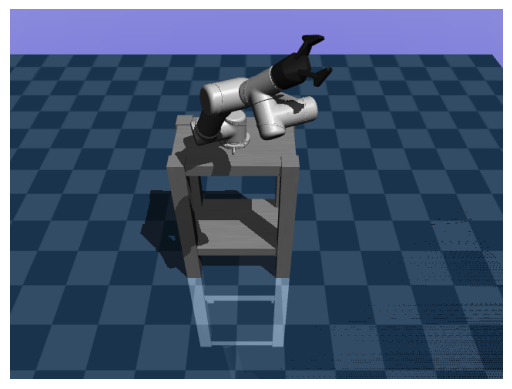

2026-05-27 00:11:08 [INFO]: Full target state: [ 1.9652 -2.2385 -0.5388  0.4754  2.1428 -1.6541  0.      0.      0.
  0.      0.      0.    ]


Warm start control simulated time: 5.0000 seconds
Warm start control execution time: 13.1555 seconds


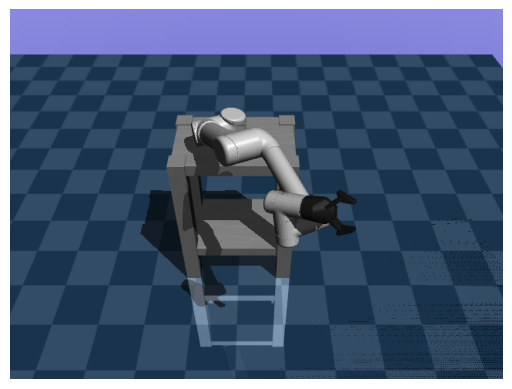

2026-05-27 00:11:22 [INFO]: Target positions: [ 1.9652 -2.2385 -0.5388  0.4754  2.1428 -1.6541]
2026-05-27 00:11:22 [INFO]: Final positions after warm start control: [ 1.9768 -2.688  -0.6045  0.4989  2.1961 -1.7072]
2026-05-27 00:11:22 [INFO]: Target velocities: [0. 0. 0. 0. 0. 0.]
2026-05-27 00:11:22 [INFO]: Final velocities after warm start control: [ 0.1903  0.1346 -0.9069 -0.0496  0.6706 -0.9121]
2026-05-27 00:11:22 [INFO]: Difference between final state and target state: [-0.0116  0.4495  0.0657 -0.0235 -0.0534  0.0531 -0.1903 -0.1346  0.9069
  0.0496 -0.6706  0.9121]
2026-05-27 00:11:22 [INFO]: last control input: [-0.236   0.8142 -0.4547 -0.0236  0.295  -0.4063]
2026-05-27 00:11:22 [INFO]: Position error norm after warm start control: 0.461202


In [8]:
import logging
from pathlib import Path
import time
import numpy as np
import mujoco
import mujoco.viewer
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPDController import RobotPDController
from optimal.utils import setup_strict_logging

setup_strict_logging(_level=logging.INFO)
VISUALIZE_WARM_START = True
# MODEL_PATH = Path.cwd().parent / "models" / "UR5gripper_2_finger_KKI.xml"
MODEL_PATH = Path.cwd().parent / "models" / "UR5_empty.xml"
MujModel = RobotMujocoModel(MODEL_PATH)
WarmStartController = RobotPDController(MujModel)
x0 = MujModel.current_state()
logging.info(f"Initial state: {np.array2string(x0, precision=4, suppress_small=True)}")

# q_target = [np.float64(-2.534909395365788), np.float64(-0.2052620169480992), np.float64(-0.6715701234164646), np.float64(0.9119147888970156), np.float64(1.8533697768029596), np.float64(1.270718240347831), np.float64(-0.7166096062697207)]
q_target = np.array(list(MujModel.random_actuated_q(ensure_feasible=True).values()))
v_target = np.zeros_like(MujModel.v_indices(), dtype=float)
x_target = np.concatenate([q_target, v_target])
MujModel.data.qpos[MujModel.q_indices()] = x_target[:MujModel.q_indices().size]
mujoco.mj_forward(MujModel.model, MujModel.data)
MujModel.snapshot(plot=True)
MujModel.reset()  # reset to initial state (q0, v0)
logging.info(f"Full target state: {np.array2string(x_target, precision=4, suppress_small=True)}")

TOTAL_TIME = 5.0 #seconds
CONTROL_DT = 0.02  # optimize at 50 Hz instead of every MuJoCo substep
N_SUBSTEPS = max(1, int(round(CONTROL_DT / MujModel.model.opt.timestep)))
HORIZON = int(TOTAL_TIME / CONTROL_DT)
warm_xs, warm_us = WarmStartController.compute_control(x0, x_target, HORIZON, CONTROL_DT, control_noise_std=0.5)
# warm_xs, warm_us = WarmStartController.compute_control(x0, x_target, HORIZON, CONTROL_DT)
warm_xs, warm_us = list(np.repeat(warm_xs, N_SUBSTEPS, axis=0)), list(np.repeat(warm_us, N_SUBSTEPS, axis=0))

start_wall_time = time.time()
start_sim_time = MujModel.data.time
if VISUALIZE_WARM_START:
    with mujoco.viewer.launch_passive(MujModel.model, MujModel.data) as viewer:
        for u_cmd in warm_us:
            MujModel.data.ctrl[:] = u_cmd
            mujoco.mj_step(MujModel.model, MujModel.data)
            viewer.sync()
end_sim_time = MujModel.data.time
print(f"Warm start control simulated time: {end_sim_time - start_sim_time:.4f} seconds")
end_wall_time = time.time()
print(f"Warm start control execution time: {end_wall_time - start_wall_time:.4f} seconds")
MujModel.snapshot(plot=True)

x_end = MujModel.current_state()
q_err = np.linalg.norm(x_end[:MujModel.q_indices().size] - x_target[:MujModel.q_indices().size])
logging.info(f"Target positions: {np.array2string(x_target[:MujModel.q_indices().size], precision=4, suppress_small=True)}")
logging.info(f"Final positions after warm start control: {np.array2string(x_end[:MujModel.q_indices().size], precision=4, suppress_small=True)}")
logging.info(f"Target velocities: {np.array2string(x_target[MujModel.q_indices().size:], precision=4, suppress_small=True)}")
logging.info(f"Final velocities after warm start control: {np.array2string(x_end[MujModel.q_indices().size:], precision=4, suppress_small=True)}")
logging.info(f"Difference between final state and target state: {np.array2string(x_target - x_end, precision=4, suppress_small=True)}")
logging.info(f"last control input: {np.array2string(warm_us[-1], precision=4, suppress_small=True)}")
logging.info(f"Position error norm after warm start control: {q_err:.6f}")

In [5]:
noise = [np.random.normal(scale=0.1, size=warm_us[0].shape) for _ in range(len(warm_us))]
warm_us_noisy = [u + n for u, n in zip(warm_us, noise)] 

MujModel.reset()  # reset to initial state (q0, v0)
if VISUALIZE_WARM_START:
    with mujoco.viewer.launch_passive(MujModel.model, MujModel.data) as viewer:
        for u_cmd in warm_us_noisy:
            for _ in range(N_SUBSTEPS):
                MujModel.data.ctrl[:] = u_cmd
                mujoco.mj_step(MujModel.model, MujModel.data)
                viewer.sync()

x_end = MujModel.current_state()
q_err = np.linalg.norm(x_end[:MujModel.q_indices().size] - x_target[:MujModel.q_indices().size])
print(f"Position error norm after warm start control with noise: {q_err:.6f}")

Position error norm after warm start control with noise: 1.677048


In [9]:
from optimal.RobotCrocoddylController import RobotCrocoddylController
MujModel.reset()  # reset to initial state (q0, v0)
CONTROL_DT = 0.02  # optimize at 50 Hz instead of every MuJoCo substep
N_SUBSTEPS = max(1, int(round(CONTROL_DT / MujModel.model.opt.timestep)))
warm_xs, warm_us_noisy = list(np.repeat(warm_xs, N_SUBSTEPS, axis=0)), list(np.repeat(warm_us_noisy, N_SUBSTEPS, axis=0))
CrocoddylController = RobotCrocoddylController(
    MujModel, 
    x_target, 
    dt=CONTROL_DT,
    running_weights=(10.0, 0.0, 1e-2),     # w_q, w_v, w_u
    terminal_weights=(1000.0, 10.0, 0.0)    # massive penalty on final pose/velocity
)
crocoddyl_xs, crocoddyl_us = CrocoddylController.get_control(warm_xs, warm_us_noisy, x0, solver='FDDP')
print("Crocoddyl optimization complete.")

import time
import mujoco
import mujoco.viewer

MujModel.reset()  # reset to initial state (q0, v0)

print(len(crocoddyl_xs))

with mujoco.viewer.launch_passive(MujModel.model, MujModel.data) as viewer:
    for u_cmd in crocoddyl_us:
        MujModel.data.ctrl[:] = u_cmd
        mujoco.mj_step(MujModel.model, MujModel.data)
        viewer.sync()
    input("Press Enter to continue...")
x_end = MujModel.current_state()
q_err = np.linalg.norm(x_end[:MujModel.q_indices().size] - x_target[:MujModel.q_indices().size])
print(f'Open-loop final q error: {q_err:.4f}')
MujModel.snapshot(plot=True)


Exception: In /project/src/core/solver-base.cpp
void crocoddyl::SolverAbstract::setCandidate(const std::vector<Eigen::Matrix<double, -1, 1>, std::allocator<Eigen::Matrix<double, -1, 1> > >&, const std::vector<Eigen::Matrix<double, -1, 1>, std::allocator<Eigen::Matrix<double, -1, 1> > >&, bool) 227
Warm start state vector has wrong dimension, got 251000 expecting 25001

In [5]:
from optimal.RobotCrocoddylController import RobotCrocoddylController
import numpy as np
import mujoco.viewer

warm_xs, warm_us = WarmStartController.compute_control(x0, x_target, HORIZON, CONTROL_DT, control_noise_std=0.5)

MujModel.reset()
x0 = MujModel.current_state()

CONTROL_DT = 0.02
mj_dt = MujModel.model.opt.timestep
N_SUBSTEPS = max(1, int(round(CONTROL_DT / mj_dt)))

# warm_xs / warm_us are currently on substep grid -> downsample for Crocoddyl
warm_xs_ctrl = list(np.asarray(warm_xs)[::N_SUBSTEPS])
warm_us_ctrl = list(np.asarray(warm_us)[::N_SUBSTEPS])

# keep shooting consistency
if len(warm_xs_ctrl) != len(warm_us_ctrl) + 1:
    warm_xs_ctrl = warm_xs_ctrl[:len(warm_us_ctrl) + 1]

CrocoddylController = RobotCrocoddylController(
    MujModel,
    x_target,
    dt=CONTROL_DT,
    running_weights=(10.0, 0.0, 1e-2),
    terminal_weights=(1000.0, 10.0, 0.0),
)

crocoddyl_xs_ctrl, crocoddyl_us_ctrl = CrocoddylController.get_control(
    warm_xs_ctrl, warm_us_ctrl, x0, solver="FDDP"
)

# repeat AFTER optimization for your simple one-step playback loop
crocoddyl_us_sub = np.repeat(np.asarray(crocoddyl_us_ctrl), N_SUBSTEPS, axis=0)

MujModel.reset()
with mujoco.viewer.launch_passive(MujModel.model, MujModel.data) as viewer:
    for u_cmd in crocoddyl_us_sub:
        MujModel.data.ctrl[:] = u_cmd
        mujoco.mj_step(MujModel.model, MujModel.data)
        viewer.sync()

In [ ]:
from optimal.RobotCrocoddylController import RobotCrocoddylController
import time
import mujoco
import mujoco.viewer

MujModel.reset()  # reset to initial state (q0, v0)
x0 = MujModel.current_state()

HORIZON = 120
CONTROL_DT = 0.02  # optimize at 50 Hz instead of every MuJoCo substep
N_SUBSTEPS = max(1, int(round(CONTROL_DT / MujModel.model.opt.timestep)))
MAX_MPC_STEPS = 1000

WarmStartController = RobotPDController(MujModel)
warm_xs, warm_us = WarmStartController.compute_control(x0, x_target, HORIZON, CONTROL_DT)
CrocoddylController = RobotCrocoddylController(
    MujModel, 
    x_target, 
    dt=CONTROL_DT,
    running_weights=(2.0, 0.01, 1e-4),     # w_q, w_v, w_u
    terminal_weights=(1000.0, 2.0, 0.0)    # massive penalty on final pose/velocity
)
warm_xs, warm_us = CrocoddylController.get_control(warm_xs, warm_us, x0, solver='FDDP')

MujModel.reset()  # reset to initial state (q0, v0)
with mujoco.viewer.launch_passive(MujModel.model, MujModel.data) as viewer:
    for step in range(MAX_MPC_STEPS):
        if not viewer.is_running():
            break
        x0 = MujModel.current_state()
        q_err = np.linalg.norm(x0[:MujModel.q_indices().size] - x_target[:MujModel.q_indices().size])
        v_err = np.linalg.norm(x0[MujModel.q_indices().size:])
        if q_err < 1e-2 and v_err < 1e-2:
            print(f'Reached target in {step} MPC updates: q_err={q_err:.4f}, v_err={v_err:.4f}')
            break

        warm_xs = list(warm_xs)
        warm_us = list(warm_us)
        warm_xs = warm_xs[1:] + [warm_xs[-1]]
        warm_us = warm_us[1:] + [warm_us[-1]]
        warm_xs[0] = x0.copy()

        crocoddyl_xs, crocoddyl_us = CrocoddylController.get_control(
            warm_xs, warm_us, x0, use_previous_attrs=True
        )
        u0 = np.asarray(crocoddyl_us[0], dtype=float)
        for _ in range(N_SUBSTEPS):
            MujModel.data.ctrl[:] = u0
            mujoco.mj_step(MujModel.model, MujModel.data)
            viewer.sync()
            time.sleep(MujModel.model.opt.timestep)

        warm_xs, warm_us = list(crocoddyl_xs), list(crocoddyl_us)
    else:
        print(f'Max MPC steps reached: q_err={q_err:.4f}, v_err={v_err:.4f}')

